# See and compare already computed GSEA an ORA

In [19]:
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

In [2]:
comparison = 'young.vs.old'
experiment = "RNAseq_abundances_adjusted_combat_inmose"


In [3]:
ora_fdr = 0.15
gsea_fdr=0.01
score_name='stat'

In [4]:
gsea_df = pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_GSEA.csv', index_col=0)
ora_df = pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', index_col=0)

In [5]:
gsea_scores = pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_DDS.csv',index_col=0)

In [6]:
gsea_scores=pd.DataFrame(gsea_scores[score_name])
gsea_scores

,stat
TSPAN6,-0.373394
TNMD,-0.305723
DPM1,-0.922960
SCYL3,-2.114769
FIRRM,-2.256718
...,...
C4orf36.1,-1.591932
Unnamed: 34327,-0.072975
H2BK1,0.009957
Unnamed: 34332,1.347965


In [7]:
ora_df=ora_df[ora_df['FDR p-value']<ora_fdr]
gsea_df=gsea_df[gsea_df['FDR p-value']<gsea_fdr]

In [8]:
ora_df.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
2201,GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_CYTOCHRO...,24,0.208333,0.000042,0.141564,13.568897,136.790511,COX4I1;COX5B;COX7C;CYCS;MT-CO2
8754,HALLMARK_OXIDATIVE_PHOSPHORYLATION,200,0.065000,0.000035,0.141564,4.133956,42.470246,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;CYCS;LDHA;ND...
10924,KEGG_OXIDATIVE_PHOSPHORYLATION,129,0.077519,0.000064,0.141564,4.949931,47.783144,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;MT-CO2;NDUFB...
13111,MOOTHA_VOXPHOS,87,0.103448,0.000015,0.117128,6.621860,73.473112,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;CYCS;NDUFB4;...
14019,REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SY...,127,0.078740,0.000056,0.141564,5.028083,49.204285,ATP5MC3;ATP5MG;COX4I1;COX5B;COX7C;CYCS;MT-CO2;...


In [9]:
gsea_df.head()

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
11,AACTTT_UNKNOWN,-0.330040,-1.195860,0.0,0.0,1761,0.401476,0.302230,TTC17;BLTP3A;PCDH18;TLK2;PCK2;NR4A2;TPBG;RCBTB...
43,ACATTCC_MIR1_MIR206,-0.428510,-1.482104,0.0,0.0,286,0.482517,0.297975,CLTC;NR4A2;SLC7A2;ARRDC3;PHF6;DDX17;AZIN1;ZNF2...
48,ACCATTT_MIR522,-0.474924,-1.602348,0.0,0.0,152,0.375000,0.202853,CPD;PRPF39;CELF2;ETV1;ZRANB2;RSBN1;MYEF2;WNK3;...
146,AKT_UP_MTOR_DN.V1_UP,-0.430431,-1.452030,0.0,0.0,154,0.246753,0.138072,CIR1;TESC;RASAL3;SPHK1;SUSD4;RIMKLB;PLSCR1;H4C...
225,APPIERTO_RESPONSE_TO_FENRETINIDE_DN,0.479226,1.841386,0.0,0.0,51,0.294118,0.067696,ATP5MF;IFITM3;IARS2;PPP1CC;NDUFC1;NDUFA2;COL3A...


In [10]:
msigdb_extended=pd.read_csv('../data/msigdb_extended.csv')

/tmp/ipykernel_625/3954172370.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  msigdb_extended=pd.read_csv('../data/msigdb_extended.csv')


In [11]:
# Plot
fig = plot_gsea_results(gsea_scores=gsea_scores, msigdb=msigdb_extended, term='GOCC_ACTIN_BASED_CELL_PROJECTION')


NameError: name 'plot_gsea_results' is not defined

In [ ]:
axes = fig[0].get_axes()
for ax in fig[0].axes:
    print(f"X-axis limits: {ax.get_xlim()}")
    print(f"Y-axis limits: {ax.get_ylim()}")
    print(f"Title: {ax.get_title()}")
    print(f"X-label: {ax.get_xlabel()}")
    print(f"Y-label: {ax.get_ylabel()}")

In [ ]:
ax = fig[0].gca()  # Get the current Axes instance
ax

In [ ]:
fig[0]

In [ ]:
pwd

In [12]:
def plot_gsea_results(gsea_scores, msigdb, score_name=score_name, term=None):
    """
    Plots the top GSEA results based on NES and includes leading edge genes.
    
    Parameters:
    gsea_df: DataFrame containing GSEA results with columns Term, ES, NES, NOM p-value, FDR p-value, Set size, Tag %, Rank %, Leading edge
    msigdb_df: DataFrame with gene symbols, collections, and genesets
    top_n: Number of top terms to display
    
    Returns:
    A bar plot with the top terms and their NES.
    """
    geneset= msigdb[msigdb['geneset']=='GOCC_ACTIN_BASED_CELL_PROJECTION']
    fig = dc.plot_running_score(
        df=gsea_scores,
        stat=score_name,
        net=geneset,
        source='geneset',
        target='genesymbol',
        set_name=term,
        return_fig=True
    )
    return fig

In [78]:
def plot_ora_results(ora_df, top_n=10, figsize=(10, 6), scale_odds_ratio=100, 
                     fontsize_title=16, fontsize_subtitle=14, fontsize_text=12,
                     fdr_bar_size=[0.8, 0.15, 0.03, 0.5]):
    """
    Creates a customized lollipop plot for ORA results, with bubble size for Odds Ratio and color for FDR p-value,
    including sample circles representing minimum, maximum, and median Odds Ratios positioned above the FDR bar.
    
    Parameters:
    ora_df: DataFrame containing ORA results with columns Term, Set size, Overlap ratio, p-value, FDR p-value, Odds ratio, Combined score, Features
    top_n: Number of top terms to display
    fdr_bar_seize: array with the size and postion of the FDR bar (left, bottom, width, height)
    
    
    Returns:
    fig: The figure object for further manipulation if needed.
    ax: The axes object with the plot.
    """
    
    # Sort ORA results by Combined Score and select top N
    ora_top = ora_df.sort_values(by='Combined score', ascending=False).head(top_n).copy()
    
    # Replace underscores in 'Term' with spaces for better display
    ora_top['Term'] = ora_top['Term'].str.replace('_', ' ')
    
    # Wrap long labels onto two lines if necessary
    ora_top['Term'] = ora_top['Term'].apply(lambda x: '\n'.join(textwrap.wrap(x, width=30)))
    
    # Normalize FDR p-value to range between 0 and 1 for color mapping
    norm = plt.Normalize(ora_top['FDR p-value'].min(), ora_top['FDR p-value'].max())
    
    # Calculate min, max, and median Odds Ratios
    min_odds = ora_top['Odds ratio'].min()
    max_odds = ora_top['Odds ratio'].max()
    median_odds = ora_top['Odds ratio'].median()
    
    # Create the figure and axis with a fixed width
    fig, ax = plt.subplots(figsize=figsize)  # Adjust the width (10) to your preference
    
    # Bubbles for Combined Score, sized by Odds Ratio and colored by FDR p-value
    bubble = ax.scatter(ora_top['Combined score'], ora_top['Term'], 
                         s=ora_top['Odds ratio'] * scale_odds_ratio,  # Scale the size by Odds Ratio
                         c=ora_top['FDR p-value'], cmap='viridis', norm=norm, alpha=0.8)
    
    # Colorbar for FDR p-values
    cbar = plt.colorbar(bubble, ax=ax)
    cbar.set_label('FDR p-value')
    
    # Remove the black outline from the bubbles
    bubble.set_edgecolors('none')
    
    # Add labels and title, increasing the font size
    ax.set_xlabel("Combined Score", fontsize=fontsize_subtitle)
    ax.set_ylabel("Pathway", fontsize=fontsize_subtitle)
    ax.set_title(f"Top {top_n} ORA Results by Combined Score", fontsize=fontsize_title)
    
    # Increase the font size for the y-axis labels (pathway names)
    ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)
    
    # Add vertical gridlines
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)
    
    # Remove horizontal gridlines
    ax.grid(False, axis='y')
    
    # Remove the extra square around the plot
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add sample circles for min, median, and max Odds Ratios on top of the FDR colorbar
    sample_odds_ratios = [min_odds, max_odds]
    sample_sizes = [min_odds * scale_odds_ratio, max_odds * scale_odds_ratio]
    sample_labels = ['Min', 'Max']
    
    # Position the sample bubbles above the colorbar
    for i, (size, label, odds) in enumerate(zip(sample_sizes, sample_labels, sample_odds_ratios)):
        ax.scatter([], [], s=size, color='grey', alpha=0.5, label=f'{int(odds)}')
    
    # Legend for the sample Odds Ratio bubbles, place above the colorbar
    leg = ax.legend(scatterpoints=1, frameon=False, labelspacing=1, title='Odds ratio', 
                    loc='upper center', bbox_to_anchor=(1.3, 1.05))
    
    # Adjust the colorbar position to make room for the sample circles
    cbar.ax.set_position(fdr_bar_size)  # 
    
    # Show plot with tight layout for better fitting
    plt.tight_layout()
    
    return fig, ax


Plot ORA

In [ ]:
dc.plot_dotplot(
    ora_df.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=.5,
    figsize=(5, 10)
)

/tmp/ipykernel_625/3895405580.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=fontsize_text)


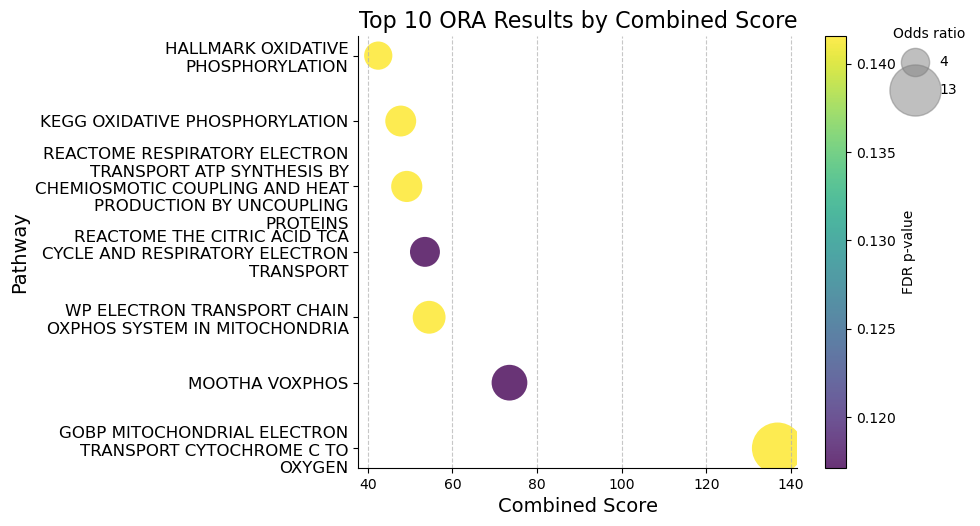

In [92]:
fig, ax = plot_ora_results(ora_df, top_n=10, figsize=(10, 6), scale_odds_ratio=100, 
                     fontsize_title=16, fontsize_subtitle=14, fontsize_text=12,
                     fdr_bar_size=[0.1, 0.05, 0.303, 0.98])

/tmp/ipykernel_625/1904397517.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ora_top['Term'], fontsize=12)


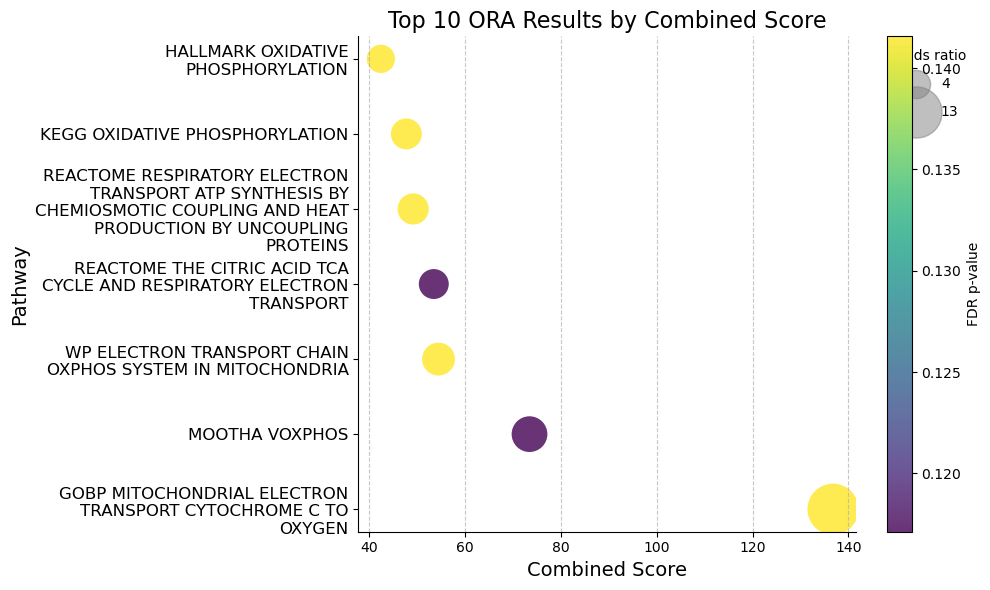

In [23]:
fig, ax = plot_ora_results(ora_df, top_n=10)

In [64]:
fig.savefig(f"results/{experiment}_{comparison}_ORA_bubble.png", bbox_inches='tight')


In [15]:
pwd

'/home/amore/work/notebooks'

In [ ]:
plot_gsea_results(gsea_df, top_n=50)